# Part C – Legal Amount Recognition
**ICS472 – Natural Language Processing**  
**Team:** Mohammed Al Sheqaih · Abdulrhman Ammar

**Goal:** Train a CRNN (CNN + BiLSTM + CTC) to decode the Arabic handwritten text from a legal amount crop. The model outputs a sequence of sub-word tokens (e.g. `['ثمانيه', 'آ', 'لا', 'ف', 'ر', 'يا', 'ل']`).

**Evaluation metrics:**
- Character Error Rate (CER) — token-level edit distance / reference length
- Word Error Rate (WER) — word-level edit distance / reference word count

> **Prerequisites:** Run `01_Part_A_Detection.ipynb` first — this notebook loads the legal crops from `artifacts/crops/`.

## 1. Imports & Setup

In [1]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from utils import (
    TRAIN_LA, TEST_LA, ARTIFACTS,
    parse_legal_amounts, build_vocab, legal_summary, edit_distance
)

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.dpi'] = 120

CROPS_DIR = ARTIFACTS / 'crops'
MODEL_DIR = ARTIFACTS / 'legal_model'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
# legal crops are bigger and the sequences are longer than courtesy
# 160px minimum width → T≥40 time steps after CNN, which covers max label length of 29

IMG_H    = 32
MIN_W    = 160
HIDDEN   = 256
N_LSTM   = 2
EPOCHS   = 150
BATCH    = 16     # legal crops are wider → smaller batch to fit memory
LR       = 5e-4
PATIENCE = 25

Device: cuda


## 2. Vocabulary & Labels

In [2]:

vocab_path = ARTIFACTS / 'la_vocab.json'
if vocab_path.exists():
    with open(vocab_path, encoding='utf-8') as f:
        vdata = json.load(f)
    la_vocab = vdata['vocab']
    la_t2i   = vdata['t2i']
    la_i2t   = {int(k): v for k, v in vdata['i2t'].items()}
    print(f'Vocabulary loaded from file ({len(la_vocab)} tokens).')
else:
    train_la = parse_legal_amounts(TRAIN_LA)
    test_la  = parse_legal_amounts(TEST_LA)
    all_seqs = list(train_la.values()) + list(test_la.values())
    la_vocab, la_t2i, la_i2t = build_vocab(all_seqs)
    print(f'Vocabulary built inline ({len(la_vocab)} tokens).')

BLANK     = 0
N_CLASSES = len(la_vocab)
print(f'Legal vocab size: {N_CLASSES}')

Vocabulary loaded from file (288 tokens).
Legal vocab size: 288


In [3]:
train_labels = parse_legal_amounts(TRAIN_LA)
test_labels  = parse_legal_amounts(TEST_LA)

print(f'Train labels: {len(train_labels)}')
print(f'Test  labels: {len(test_labels)}')


train_lens = [len(v) for v in train_labels.values()]
print(f'\nTrain sequence length — min: {min(train_lens)}, '
      f'max: {max(train_lens)}, avg: {np.mean(train_lens):.1f}')

# make sure there are no surprise OOV tokens at inference time
oov = set()
for tokens in list(train_labels.values()) + list(test_labels.values()):
    oov.update(t for t in tokens if t not in la_t2i)
print(f'OOV tokens: {len(oov)}  (should be 0 if vocab built from train+test)')

Train labels: 1799
Test  labels: 600

Train sequence length — min: 4, max: 37, avg: 14.4
OOV tokens: 0  (should be 0 if vocab built from train+test)


## 3. Dataset & DataLoader

In [4]:
class LegalDataset(Dataset):
    def __init__(self, crops_dir, labels, t2i, img_h=32, min_w=160):
        self.t2i   = t2i
        self.img_h = img_h
        self.min_w = min_w
        self.samples = []

        for img_path in sorted(crops_dir.glob('*.tif')):
            key = img_path.name  # e.g. Lac00000.tif
            if key in labels and len(labels[key]) > 0:
                self.samples.append((img_path, labels[key]))

        print(f'Dataset: {len(self.samples)} samples from {crops_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, token_seq = self.samples[idx]
        img = Image.open(img_path).convert('L')

        # Resize to fixed height, preserve aspect ratio, enforce min width
        w, h  = img.size
        new_w = max(self.min_w, int(w * self.img_h / h))
        img   = img.resize((new_w, self.img_h), Image.BILINEAR)

        img_t = T.ToTensor()(img)   # (1, H, W), range [0, 1]

        label = torch.tensor(
            [self.t2i[t] for t in token_seq if t in self.t2i],
            dtype=torch.long
        )
        return img_t, label


def collate_fn(batch):
    imgs, labels = zip(*batch)
    max_w  = max(img.shape[2] for img in imgs)
    padded = torch.ones(len(imgs), 1, IMG_H, max_w)  # 1.0 = white
    for i, img in enumerate(imgs):
        padded[i, :, :, :img.shape[2]] = img

    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_cat    = torch.cat(labels)
    input_lengths = torch.tensor(
        [max_w // 4 for _ in imgs], dtype=torch.long
    )
    return padded, labels_cat, input_lengths, label_lengths


train_ds = LegalDataset(CROPS_DIR / 'train' / 'legal', train_labels, la_t2i, IMG_H, MIN_W)
test_ds  = LegalDataset(CROPS_DIR / 'test'  / 'legal', test_labels,  la_t2i, IMG_H, MIN_W)

val_size   = int(0.1 * len(train_ds))
train_size = len(train_ds) - val_size
train_sub, val_sub = torch.utils.data.random_split(
    train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# num_workers=0 avoids Windows multiprocessing stdout issues in Jupyter
train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_sub,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=True)

print(f'Train: {train_size} | Val: {val_size} | Test: {len(test_ds)}')


Dataset: 1798 samples from C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\crops\train\legal
Dataset: 600 samples from C:\Users\Admin\Desktop\NLP_Project\arabic-bank-check-processing\codebase\artifacts\crops\test\legal
Train: 1619 | Val: 179 | Test: 600


## 4. CRNN Model

Same architecture as Part B — 7-block CNN backbone, 2-layer BiLSTM, CTC head — with a larger output layer to match the legal vocabulary size (~130 tokens vs 13 for courtesy).

```
Input  (B, 1, 32, W)
  │
  ▼
CNN  →  (B, 512, 1, W//4)    height collapsed to 1, width becomes time axis
  │
  ▼
BiLSTM  (2 layers, 256 units each direction)  →  (T, B, 512)
  │
  ▼
Linear  →  (T, B, legal_vocab_size)  →  CTC Loss
```

In [5]:
def conv_bn_relu(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class CRNN(nn.Module):
    def __init__(self, n_classes, hidden=256, n_lstm=2):
        super().__init__()
        self.cnn = nn.Sequential(
            conv_bn_relu(1,   64),  nn.MaxPool2d(2, 2),
            conv_bn_relu(64,  128), nn.MaxPool2d(2, 2),
            conv_bn_relu(128, 256), conv_bn_relu(256, 256), nn.MaxPool2d((2, 1)),
            conv_bn_relu(256, 512), conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
            conv_bn_relu(512, 512), nn.MaxPool2d((2, 1)),
        )
        self.lstm = nn.LSTM(
            input_size=512, hidden_size=hidden,
            num_layers=n_lstm, bidirectional=True,
            batch_first=False, dropout=0.2 if n_lstm > 1 else 0
        )
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        x = self.cnn(x)          # (B, 512, 1, W//4)
        x = x.squeeze(2)         # (B, 512, T)
        x = x.permute(2, 0, 1)  # (T, B, 512)
        x, _ = self.lstm(x)      # (T, B, 512)
        x = self.fc(x)           # (T, B, n_classes)
        return torch.log_softmax(x, dim=-1)


model = CRNN(N_CLASSES, hidden=HIDDEN, n_lstm=N_LSTM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CRNN parameters: {total_params:,}')

CRNN parameters: 10,165,664


## 5. Training

In [6]:
def greedy_decode(log_probs, i2t, blank=0):
    indices = log_probs.argmax(dim=-1).cpu().tolist()
    tokens, prev = [], None
    for idx in indices:
        if idx != prev:
            tokens.append(idx)
        prev = idx
    return [i2t[i] for i in tokens if i != blank]


def token_accuracy(refs, hyps):
    """Token-level accuracy (1 - CER) for progress monitoring."""
    total_N, total_ed = 0, 0
    for r, h in zip(refs, hyps):
        total_ed += edit_distance(r, h)
        total_N  += len(r)
    cer = total_ed / max(total_N, 1)
    return max(0.0, (1 - cer)) * 100


def run_epoch(loader, model, criterion, optimiser=None):
    training = optimiser is not None
    model.train() if training else model.eval()
    total_loss = 0
    refs, hyps = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels, in_lens, lbl_lens in loader:
            imgs = imgs.to(DEVICE)

            log_probs = model(imgs)
            T_actual  = log_probs.size(0)
            in_lens   = torch.clamp(in_lens, max=T_actual)

            loss = criterion(
                log_probs, labels.to(DEVICE),
                in_lens.to(DEVICE), lbl_lens.to(DEVICE)
            )

            if training:
                optimiser.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimiser.step()

            total_loss += loss.item()

            offset = 0
            for i, llen in enumerate(lbl_lens.tolist()):
                ref = [la_i2t[idx] for idx in labels[offset:offset+llen].tolist()]
                hyp = greedy_decode(log_probs[:, i, :], la_i2t)
                refs.append(ref); hyps.append(hyp)
                offset += llen

    acc = token_accuracy(refs, hyps)
    return total_loss / len(loader), acc


criterion = nn.CTCLoss(blank=BLANK, reduction='mean', zero_infinity=True)
optimiser = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode='max', factor=0.5, patience=8, min_lr=1e-5
)

best_val_acc = -1
patience_ctr = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimiser)
    vl_loss, vl_acc = run_epoch(val_loader,   model, criterion)
    scheduler.step(vl_acc)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_DIR / 'best.pt')
        flag = ' ✓'
    else:
        patience_ctr += 1
        flag = ''

    print(f'Epoch {epoch:>3}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.1f}% | '
          f'val loss {vl_loss:.4f} acc {vl_acc:.1f}%{flag}',
          flush=True)

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).', flush=True)
        break

print(f'\nBest val token accuracy: {best_val_acc:.2f}%', flush=True)


Epoch   1/150 | train loss 5.1782 acc 0.0% | val loss 3.2765 acc 0.0% ✓
Epoch   2/150 | train loss 2.9286 acc 6.3% | val loss 2.7110 acc 17.1% ✓
Epoch   3/150 | train loss 2.5249 acc 20.4% | val loss 2.4635 acc 23.1% ✓
Epoch   4/150 | train loss 2.3587 acc 27.1% | val loss 2.3164 acc 29.3% ✓
Epoch   5/150 | train loss 2.2715 acc 28.7% | val loss 2.2817 acc 30.0% ✓
Epoch   6/150 | train loss 2.2293 acc 31.7% | val loss 2.2455 acc 34.9% ✓
Epoch   7/150 | train loss 2.1669 acc 35.2% | val loss 2.4376 acc 37.6% ✓
Epoch   8/150 | train loss 2.1252 acc 36.3% | val loss 2.1632 acc 38.5% ✓
Epoch   9/150 | train loss 2.1044 acc 36.4% | val loss 2.1737 acc 33.1%
Epoch  10/150 | train loss 2.0837 acc 35.6% | val loss 2.1842 acc 33.6%
Epoch  11/150 | train loss 2.0557 acc 36.6% | val loss 2.0989 acc 36.4%
Epoch  12/150 | train loss 2.0264 acc 37.7% | val loss 2.1373 acc 40.9% ✓
Epoch  13/150 | train loss 2.0101 acc 38.2% | val loss 2.0661 acc 37.9%
Epoch  14/150 | train loss 1.9769 acc 39.3% | val

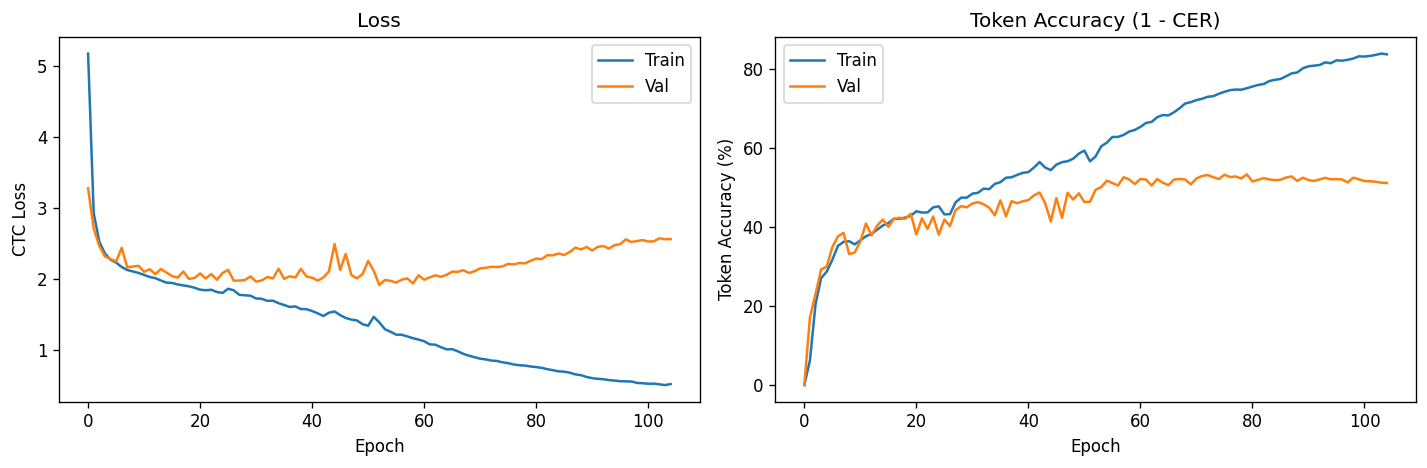

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('CTC Loss')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Token Accuracy (%)')
ax2.set_title('Token Accuracy (1 - CER)'); ax2.legend()

plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_training_curves.png', bbox_inches='tight')
plt.show()

## 6. Evaluation on Test Set

In [9]:
model.load_state_dict(torch.load(MODEL_DIR / 'best.pt', map_location=DEVICE))
model.eval()

all_refs, all_hyps = [], []

with torch.no_grad():
    for imgs, labels, in_lens, lbl_lens in tqdm(test_loader, desc='Test eval'):
        imgs      = imgs.to(DEVICE)
        log_probs = model(imgs)
        T_actual  = log_probs.size(0)
        in_lens   = torch.clamp(in_lens, max=T_actual)

        offset = 0
        for i, llen in enumerate(lbl_lens.tolist()):
            ref = [la_i2t[idx] for idx in labels[offset:offset+llen].tolist()]
            hyp = greedy_decode(log_probs[:, i, :], la_i2t)
            all_refs.append(ref)
            all_hyps.append(hyp)
            offset += llen

metrics = legal_summary(all_refs, all_hyps)
print('── Test Set Results (Part C) ──')
print(f"  CER : {metrics['CER']}%")
print(f"  WER : {metrics['WER']}%")

Test eval: 100%|██████████| 38/38 [00:01<00:00, 24.93it/s]

── Test Set Results (Part C) ──
  CER : 50.5%
  WER : 99.33%


## 7. Error Analysis

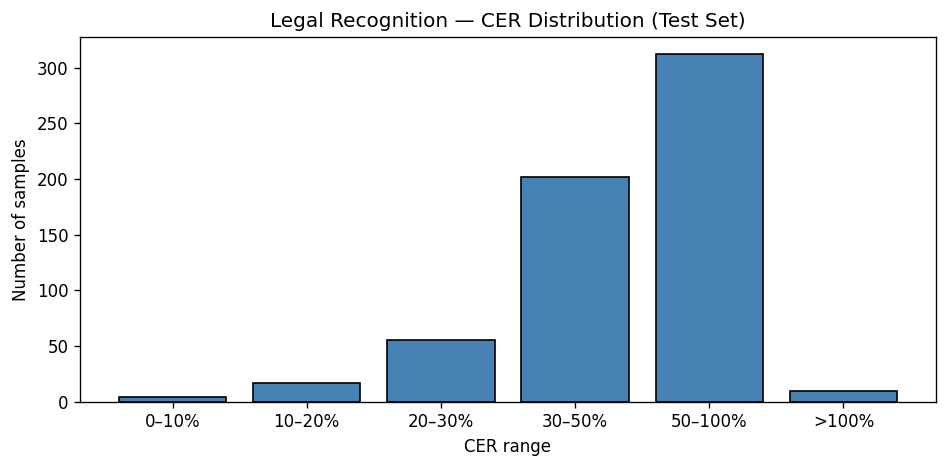

Samples with CER = 0 (perfect): 4 / 600


In [10]:
per_sample = [
    {
        'cer': edit_distance(r, h) / max(len(r), 1),
        'ref': r,
        'hyp': h,
    }
    for r, h in zip(all_refs, all_hyps)
]


cer_vals = [s['cer'] for s in per_sample]
bins = [0, 0.1, 0.2, 0.3, 0.5, 1.0, float('inf')]
bin_labels = ['0–10%', '10–20%', '20–30%', '30–50%', '50–100%', '>100%']
counts = [sum(b1 <= c < b2 for c in cer_vals) for b1, b2 in zip(bins[:-1], bins[1:])]

plt.figure(figsize=(8, 4))
plt.bar(bin_labels, counts, color='steelblue', edgecolor='black')
plt.xlabel('CER range'); plt.ylabel('Number of samples')
plt.title('Legal Recognition — CER Distribution (Test Set)')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'partC_cer_dist.png', bbox_inches='tight')
plt.show()

print(f'Samples with CER = 0 (perfect): {counts[0]} / {len(cer_vals)}')

In [11]:

sorted_samples = sorted(per_sample, key=lambda x: x['cer'])

print('── Best predictions (lowest CER) ──')
for s in sorted_samples[:5]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")

print('\n── Worst predictions (highest CER) ──')
for s in sorted_samples[-5:]:
    print(f"  CER={s['cer']:.2f} | ref: {''.join(s['ref'])} | pred: {''.join(s['hyp'])}")

── Best predictions (lowest CER) ──
  CER=0.00 | ref: فقطألفرياللاغير | pred: فقطألفرياللاغير
  CER=0.09 | ref: عشرةآلافريالفقطلاغير | pred: عشرةآلافرياللاغير
  CER=0.09 | ref: فقطعشرونألفرياللاغير | pred: فقطخمسونألفرياللاغير
  CER=0.09 | ref: عشرةآلافريالفقطلاغير | pred: عشرةآلافرياللاغير
  CER=0.10 | ref: عشرونألفرياللاغير | pred: ثلاثونألفرياللاغير

── Worst predictions (highest CER) ──
  CER=1.14 | ref: الفرياللاغير | pred: خمسةعشرألافلفوخمسمائهريال
  CER=1.17 | ref: الفريالفقط | pred: ألفوثلاثمائهوخمسونريالفقط
  CER=1.38 | ref: خمسمائةريالفقطلاغير | pred: ستعشرألفوثمانمائهةوثمانينرياللاغير
  CER=1.75 | ref: اثناعشرالفريال | pred: تسعةآلافوستمائةوخمسةوعشرنريال
  CER=2.33 | ref: ألفريالفقط | pred: فقطخمسةعشرألفوخمسمائةوخمسةعشررللاغير


In [12]:
# which tokens does the model mix up most often?
from collections import Counter

def substitution_pairs(ref, hyp):
    """Extract (ref_token, hyp_token) substitution pairs via DP alignment."""
    n, m = len(ref), len(hyp)
    # Build DP table with backpointers
    dp = [[(0, '')] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1): dp[i][0] = (i, 'D')
    for j in range(m + 1): dp[0][j] = (j, 'I')
    dp[0][0] = (0, '')
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref[i-1] == hyp[j-1]:
                dp[i][j] = (dp[i-1][j-1][0], 'M')
            else:
                best = min(
                    (dp[i-1][j][0] + 1, 'D'),
                    (dp[i][j-1][0] + 1, 'I'),
                    (dp[i-1][j-1][0] + 1, 'S'),
                )
                dp[i][j] = best
    # Backtrace
    pairs = []
    i, j = n, m
    while i > 0 or j > 0:
        _, op = dp[i][j]
        if op == 'S':
            pairs.append((ref[i-1], hyp[j-1]))
            i -= 1; j -= 1
        elif op == 'D':
            i -= 1
        elif op == 'I':
            j -= 1
        else:  # M
            i -= 1; j -= 1
    return pairs

sub_counter = Counter()
for r, h in zip(all_refs, all_hyps):
    sub_counter.update(substitution_pairs(r, h))

print('Top 10 most common substitutions (ref → pred):')
for (ref_tok, hyp_tok), cnt in sub_counter.most_common(10):
    print(f'  "{ref_tok}" → "{hyp_tok}"  ({cnt}×)')

Top 10 most common substitutions (ref → pred):
  "ا" → "أ"  (100×)
  "ئه" → "ة"  (53×)
  "ر" → "ة"  (40×)
  "ر" → "و"  (39×)
  "لا" → "ل"  (39×)
  "ا" → "آ"  (35×)
  "ا" → "ة"  (29×)
  "لا" → "لف"  (25×)
  "ئة" → "ة"  (23×)
  "ا" → "خمس"  (23×)


## 8. Save Predictions

In [13]:
predictions_out = []
for (img_path, ref_tokens), hyp in zip(test_ds.samples, all_hyps):
    fname = img_path.name                   # Lac03000.tif
    stem  = fname[1:].replace('.tif', '')   # ac03000
    predictions_out.append({
        'file':      fname,
        'stem':      stem,
        'reference': ' '.join(ref_tokens),
        'predicted': ' '.join(hyp),
    })

with open(ARTIFACTS / 'partC_predictions.json', 'w', encoding='utf-8') as f:
    json.dump(predictions_out, f, indent=2, ensure_ascii=False)

with open(ARTIFACTS / 'partC_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Predictions and metrics saved to artifacts/')

Predictions and metrics saved to artifacts/


## 9. Summary

In [14]:
print('── Part C Complete ──')
print(f"  Model         : CRNN (CNN + BiLSTM×{N_LSTM} + CTC)")
print(f"  Vocab size    : {N_CLASSES} sub-word tokens")
print(f"  Parameters    : {total_params:,}")
print(f"  Best val acc  : {best_val_acc:.2f}% (1 - CER)")
print()
print(f"  Test results:")
print(f"    CER : {metrics['CER']}%")
print(f"    WER : {metrics['WER']}%")
print()
print('  → Run 04_Part_D_Verification.ipynb next')

── Part C Complete ──
  Model         : CRNN (CNN + BiLSTM×2 + CTC)
  Vocab size    : 288 sub-word tokens
  Parameters    : 10,165,664
  Best val acc  : 53.32% (1 - CER)

  Test results:
    CER : 50.5%
    WER : 99.33%

  → Run 04_Part_D_Verification.ipynb next
